# Conventional CNN for PCB Defect Detection

This notebook implements a conventional Convolutional Neural Network (CNN) for detecting and classifying defects in Printed Circuit Boards (PCBs). The model is trained on labeled PCB images to identify various types of defects in manufacturing quality control.

## Dataset
- **Source**: PCB defect detection dataset from Kaggle
- **Format**: JPG images with corresponding JSON annotation files
- **Labels**: Various defect types (excluding 'good' and 'no_good' samples)
- **Location**: `../dataset/Labeled/`

In [1]:
# Standard library imports
import os
import json
import math

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Image processing
import cv2

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

All libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: []


c:\Users\david\miniconda3\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [2]:
def create_dummy_image():
    """
    Create a dummy placeholder image for visualization when actual images are not available.
    
    Returns:
        numpy.ndarray: RGB image array (100x100x3) with white background
    """
    dummy_image_path = "../dataset/nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255

## Data Loading and Preparation

The following section loads the labeled PCB images and their corresponding annotations from JSON files.

In [3]:
# Define the directory containing the labeled dataset
dataset_dir = r'C:\Users\david\Desktop\project\dataset\Labeled'
print(f"Loading data from: {dataset_dir}")

# Initialize list to store image-label pairs
data = []

# Process all JPG files in the directory
for filename in os.listdir(dataset_dir):
    if filename.lower().endswith('.jpg'):
        image_path = os.path.join(dataset_dir, filename)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        # Extract label from corresponding JSON file
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

# Create DataFrame and display basic information
df = pd.DataFrame(data)
print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(df)}")
print(f"Samples with labels: {df['label'].notna().sum()}")
print(f"Unique labels: {df['label'].unique()}")

# Display dataset info and first few rows
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()
print("\n" + "="*50)
print("FIRST 5 SAMPLES")
print("="*50)
display(df.head())

Loading data from: C:\Users\david\Desktop\project\dataset\Labeled

Dataset loaded successfully!
Total samples: 428
Samples with labels: 428
Unique labels: ['no_good' 'good' 'exc_solder' 'poor_solder' 'spike']

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB

FIRST 5 SAMPLES


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


## Data Preprocessing and Augmentation

This section prepares the data for training by filtering relevant classes, splitting into train/validation sets, and setting up data augmentation pipelines.

In [ ]:
# Filter out 'no_good' samples to focus on specific defect types
df_filtered = df[~df['label'].isin(['no_good'])].copy()
print(f"Samples after filtering: {len(df_filtered)}")
print(f"Remaining labels: {df_filtered['label'].value_counts()}")

# Configuration parameters
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"\nConfiguration:")
print(f"- Target image size: {TARGET_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Validation split: {TEST_SIZE}")

# Split data into training and validation sets
train_df, val_df = train_test_split(
    df_filtered, 
    test_size=TEST_SIZE, 
    stratify=df_filtered['label'], 
    random_state=RANDOM_STATE
)

print(f"\nData split:")
print(f"- Training samples: {len(train_df)}")
print(f"- Validation samples: {len(val_df)}")

# Create class indices mapping
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}
num_classes = len(class_indices)
print(f"\nClass mapping: {class_indices}")
print(f"Number of classes: {num_classes}")

# Define data augmentation pipeline using Albumentations
augmentation_pipeline = A.Compose([
    A.Resize(TARGET_SIZE[0], TARGET_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # ImageNet normalization
    ToTensorV2(),
])

def create_data_generator(df, batch_size, augmentations, target_size, class_indices):
    """
    Custom data generator using Albumentations for image augmentation.
    
    Args:
        df: DataFrame containing image paths and labels
        batch_size: Number of samples per batch
        augmentations: Albumentations pipeline
        target_size: Target image dimensions
        class_indices: Dictionary mapping labels to indices
        
    Yields:
        tuple: (batch of images, batch of one-hot encoded labels)
    """
    while True:
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i:i+batch_size]
            images = []
            labels = []
            
            for _, row in batch_df.iterrows():
                # Load and process image
                image = cv2.imread(row['filename'])
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                
                # Apply augmentations
                augmented = augmentations(image=image)
                image = augmented['image']
                
                # Convert to channels-last format if needed
                if image.shape[0] == 3:
                    image = np.transpose(image, (1, 2, 0))
                
                images.append(image)
                
                # Convert label to one-hot encoding
                label_idx = class_indices[row['label']]
                one_hot_label = tf.keras.utils.to_categorical(label_idx, num_classes=len(class_indices))
                labels.append(one_hot_label)
            
            yield np.array(images), np.array(labels)

# Create data generators
train_generator = create_data_generator(train_df, BATCH_SIZE, augmentation_pipeline, TARGET_SIZE, class_indices)
val_generator = create_data_generator(val_df, BATCH_SIZE, augmentation_pipeline, TARGET_SIZE, class_indices)

print("\nData generators created successfully!")

Samples after filtering: 312
Remaining labels: label
good           162
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

Configuration:
- Target image size: (224, 224)
- Batch size: 32
- Validation split: 0.2

Data split:
- Training samples: 249
- Validation samples: 63

Class mapping: {'good': 0, 'exc_solder': 1, 'spike': 2, 'poor_solder': 3}
Number of classes: 4

Data generators created successfully!


# CNN

## CNN Model Architecture and Training

Building and training a conventional Convolutional Neural Network for PCB defect classification.

In [ ]:
# Define CNN architecture
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    layers.MaxPooling2D(2, 2),
    
    # Second convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'), 
    layers.MaxPooling2D(2, 2),
    
    # Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("Model Architecture:")
print("="*50)
model.summary()

# Training configuration
EPOCHS = 10
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)
validation_steps = math.ceil(len(val_df) / BATCH_SIZE)

print(f"\nTraining Configuration:")
print(f"- Epochs: {EPOCHS}")
print(f"- Steps per epoch: {steps_per_epoch}")
print(f"- Validation steps: {validation_steps}")

# Train the model
print(f"\nStarting training...")
print("="*50)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    verbose=1
)

print("\nTraining completed!")

Model Architecture:


c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,380 (22.80 MB)

 Trainable params: 5,977,380 (22.80 MB)

 Non-trainable params: 0 (0.00 B)


Training Configuration:
- Epochs: 10
- Steps per epoch: 8
- Validation steps: 2

Starting training...
Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.3940 - loss: 9.1909 - val_accuracy: 0.5079 - val_loss: 2.3982
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 962ms/step - accuracy: 0.6430 - loss: 1.4857 - val_accuracy: 0.6032 - val_loss: 0.9641
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6865 - loss: 0.8018 - val_accuracy: 0.6349 - val_loss: 0.8567
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6426 - loss: 0.7592 - val_accuracy: 0.6349 - val_loss: 0.8382
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7044 - loss: 0.6760 - val_accuracy: 0.6825 - val_loss: 0.8166
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8021 - loss: 0.5715 - val_accuracy: 0.6508 - val_loss: 0.8322
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8292 - loss: 0.4752 - val_accuracy: 0.6825 - val_loss: 0.8345
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━


Model saved to: ../model/conventional_cnn.h5


## Training History Visualization

Visualizing the training and validation accuracy/loss curves to assess model performance.

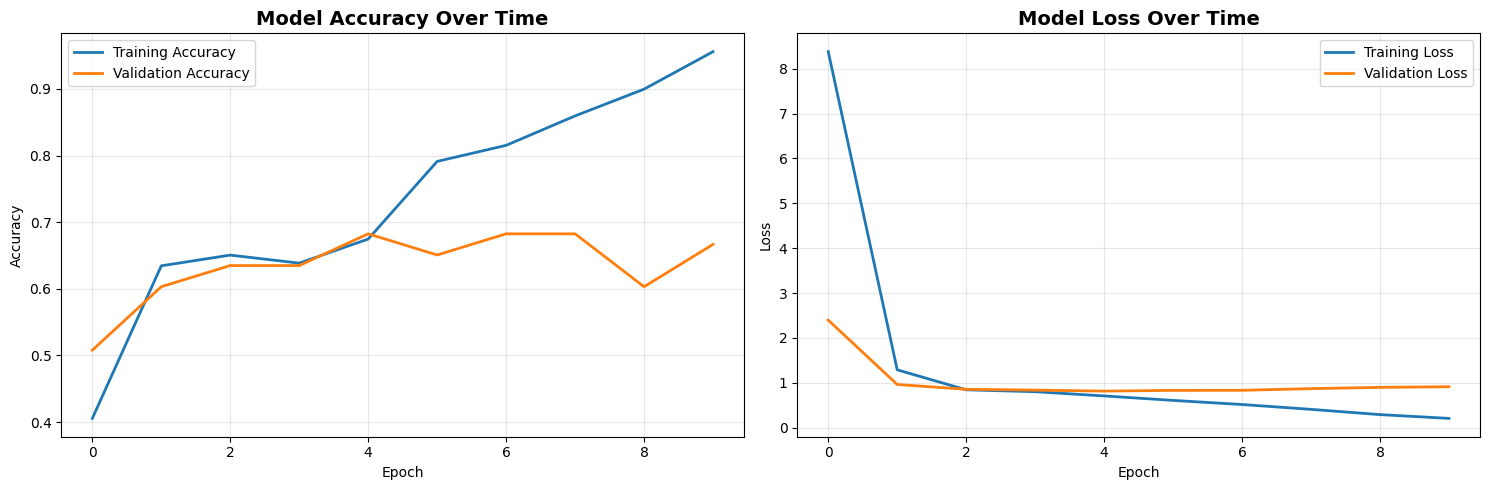


Final Training Results:
- Training Accuracy: 0.9558
- Validation Accuracy: 0.6667
- Training Loss: 0.2085
- Validation Loss: 0.9140


In [6]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final training metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Results:")
print(f"- Training Accuracy: {final_train_acc:.4f}")
print(f"- Validation Accuracy: {final_val_acc:.4f}")
print(f"- Training Loss: {final_train_loss:.4f}")
print(f"- Validation Loss: {final_val_loss:.4f}")

# Evaluation

## Model Evaluation and Analysis

Comprehensive evaluation of the trained model including classification metrics, confusion matrix, and error analysis.

Generating predictions on validation set...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
Predictions completed for 63 samples

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        good       0.84      0.82      0.83        33
  exc_solder       0.48      0.62      0.54        16
       spike       0.50      0.25      0.33         8
 poor_solder       0.33      0.33      0.33         6

    accuracy                           0.65        63
   macro avg       0.54      0.51      0.51        63
weighted avg       0.66      0.65      0.65        63



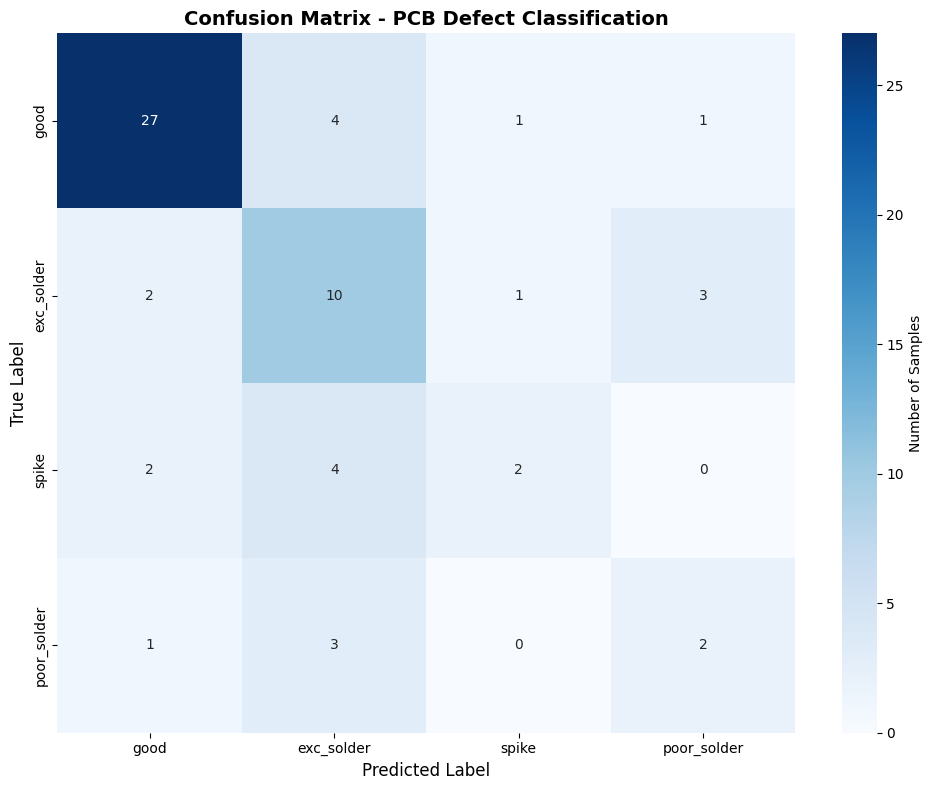


OVERALL PERFORMANCE METRICS
Accuracy:  0.6508
Precision: 0.6581
Recall:    0.6508
F1-Score:  0.6465

Creating error analysis visualization...


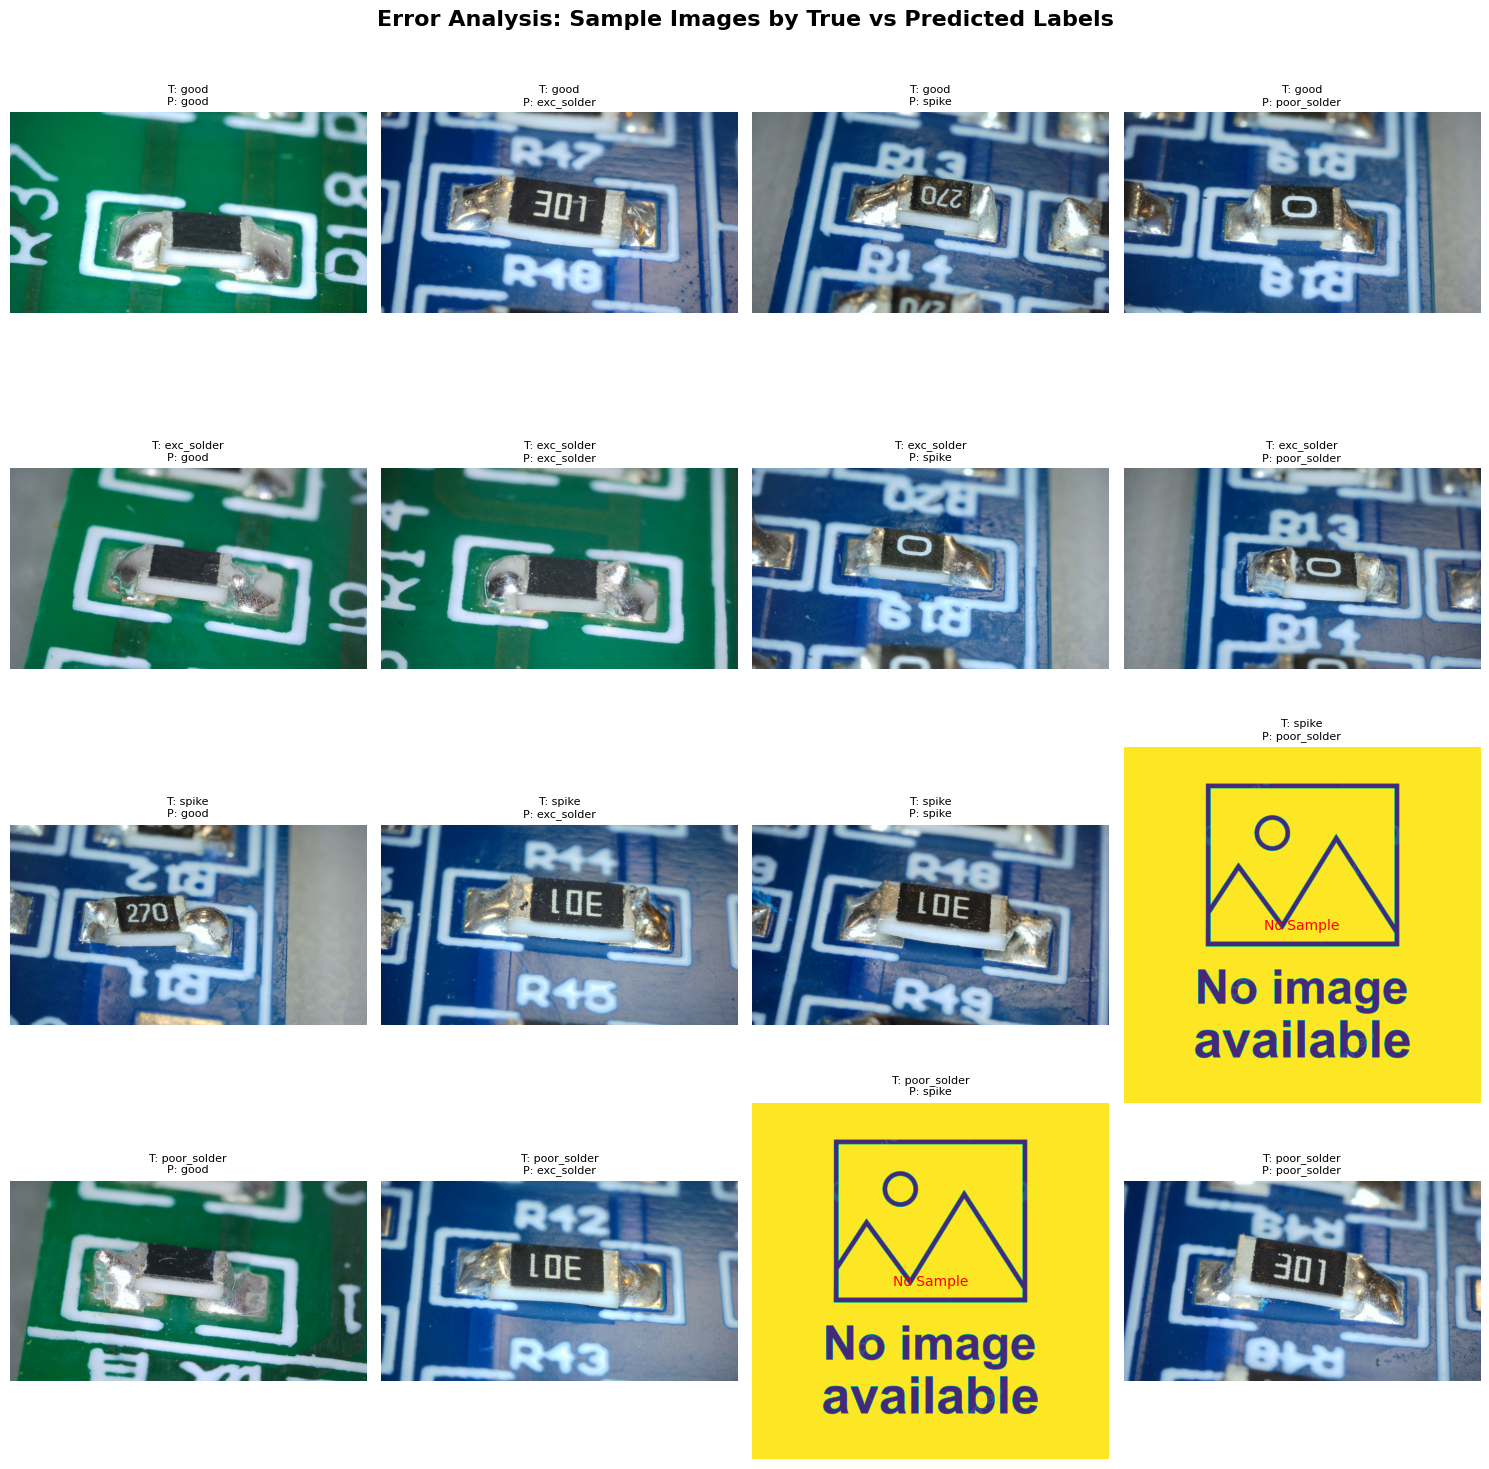

Evaluation completed!


In [7]:
# Generate predictions on validation set
print("Generating predictions on validation set...")
val_steps = math.ceil(len(val_df) / BATCH_SIZE)
predictions = model.predict(val_generator, steps=val_steps, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# Prepare ground truth labels
true_classes = val_df['label'].map(class_indices).values
class_labels = list(class_indices.keys())

print(f"Predictions completed for {len(predicted_classes)} samples")

# Generate and display classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# Create and display confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - PCB Defect Classification", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and display additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print(f"\n" + "="*50)
print("OVERALL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Error Analysis: Visual inspection of predictions
print(f"\nCreating error analysis visualization...")
fig, axes = plt.subplots(len(class_labels), len(class_labels), figsize=(15, 15))
fig.suptitle('Error Analysis: Sample Images by True vs Predicted Labels', fontsize=16, fontweight='bold')

for true_idx, true_label in enumerate(class_labels):
    for pred_idx, pred_label in enumerate(class_labels):
        # Find samples for this true/predicted combination
        indices = np.where((true_classes == true_idx) & (predicted_classes == pred_idx))[0]
        
        if len(indices) > 0:
            # Use the first sample found
            sample_idx = indices[0]
            image_path = val_df['filename'].iloc[sample_idx]
            
            # Load and display image
            if os.path.exists(image_path):
                image = plt.imread(image_path)
            else:
                image = create_dummy_image()
        else:
            # No sample exists for this combination
            image = create_dummy_image()
        
        # Plot the image
        ax = axes[true_idx, pred_idx]
        ax.imshow(image)
        ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
        if len(indices) == 0:
            ax.text(0.5, 0.5, "No Sample", transform=ax.transAxes, 
                   ha='center', va='center', fontsize=10, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("Evaluation completed!")